# Milestone 3 — Fraud Risk Prediction Model
**Folder:** Models/fraud_detection_model.ipynb
**Input:** Data/processed/transactions_model_ready.parquet
**Target:** is_aml (binary — 0 = Normal, 1 = AML)
**Output:** Trained model + evaluation metrics + saved model file

## Steps
1. Load model-ready data
2. Train/test split
3. Baseline model — Logistic Regression
4. Main models — Random Forest, XGBoost, LightGBM
5. Compare models (ROC-AUC, Precision, Recall, F1)
6. Confusion matrix & ROC curve for best model
7. Save best model

In [23]:
!pip install xgboost


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print("✅ Libraries imported")

✅ Libraries imported


In [25]:
df = pd.read_parquet(os.path.join('..', 'Data', 'processed',
                                   'transactions_model_ready.parquet'))

print("=" * 50)
print("MODEL-READY DATA LOADED")
print("=" * 50)
print(f"Shape : {df.shape}")
print()
print("Target distribution (is_aml):")
print(df['is_aml'].value_counts())
print(f"\nFraud rate: {df['is_aml'].mean()*100:.2f}%")

MODEL-READY DATA LOADED
Shape : (386570, 84)

Target distribution (is_aml):
is_aml
0    313716
1     72854
Name: count, dtype: int64

Fraud rate: 18.85%


## Step 1 — Prepare Features and Target

For M3 (fraud detection), we use:
- **Target**: `is_aml` (binary)
- **Features**: all top-80 selected features

We drop the M4-related columns (`aml_typology`, `aml_typology_original`,
`aml_typology_code`) since M3 only predicts fraud risk, not typology.

In [26]:
# Columns NOT used as features for M3
target_and_typology_cols = [
    'is_aml', 'aml_typology',
    'aml_typology_original', 'aml_typology_code'
]

X = df.drop(columns=[c for c in target_and_typology_cols
                     if c in df.columns])
y = df['is_aml']

print(f"Feature matrix X : {X.shape}")
print(f"Target y         : {y.shape}")
print(f"Feature columns  : {X.shape[1]}")

Feature matrix X : (386570, 80)
Target y         : (386570,)
Feature columns  : 80


## Step 2 — Train/Test Split

80% training, 20% testing.
`stratify=y` ensures both sets have the same 18.9% fraud ratio.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print(f"Train set : {X_train.shape}  | Fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test set  : {X_test.shape}   | Fraud rate: {y_test.mean()*100:.2f}%")

Train set : (309256, 80)  | Fraud rate: 18.85%
Test set  : (77314, 80)   | Fraud rate: 18.85%


## Step 3 — Baseline Model: Logistic Regression

Logistic Regression is our baseline — simple, fast, interpretable.
Any advanced model (Random Forest, XGBoost, LightGBM) must beat this.

`class_weight='balanced'` handles the 81/19 imbalance automatically.

In [28]:
# Scale features for Logistic Regression (it's sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42)

log_reg.fit(X_train_scaled, y_train)

# Predict
y_pred_lr  = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("=" * 50)
print("LOGISTIC REGRESSION — BASELINE")
print("=" * 50)
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")

LOGISTIC REGRESSION — BASELINE
ROC-AUC   : 0.8439
Precision : 0.4516
Recall    : 0.7354
F1 Score  : 0.5596
Accuracy  : 0.7818


## Step 4 — Random Forest

Tree-based ensemble model — handles non-linear patterns
and feature interactions better than Logistic Regression.
No scaling needed for tree-based models.

In [29]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_rf):.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")

RANDOM FOREST
ROC-AUC   : 0.9256
Precision : 0.5712
Recall    : 0.8663
F1 Score  : 0.6884
Accuracy  : 0.8522


## Step 5 — XGBoost

Gradient boosting — usually the strongest performer for
tabular fraud detection tasks. `scale_pos_weight` handles imbalance.

In [30]:
# scale_pos_weight = (negative class count) / (positive class count)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1)

xgb.fit(X_train, y_train)

y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("=" * 50)
print("XGBOOST")
print("=" * 50)
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_xgb):.4f}")

XGBOOST
ROC-AUC   : 0.9409
Precision : 0.6346
Recall    : 0.8657
F1 Score  : 0.7324
Accuracy  : 0.8808


## Step 6 — LightGBM

Faster alternative to XGBoost, often similar or better performance
on large tabular datasets like ours (386k rows).

In [31]:
lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    verbose=-1)

lgbm.fit(X_train, y_train)

y_pred_lgbm  = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("=" * 50)
print("LIGHTGBM")
print("=" * 50)
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_lgbm):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lgbm):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lgbm):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_lgbm):.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lgbm):.4f}")

LIGHTGBM
ROC-AUC   : 0.9412
Precision : 0.6331
Recall    : 0.8654
F1 Score  : 0.7312
Accuracy  : 0.8801


## Step 7 — Compare All Models

Side-by-side comparison table + bar chart of all 4 models
across ROC-AUC, Precision, Recall, and F1.

              Model  ROC-AUC  Precision  Recall     F1
           LightGBM   0.9412     0.6331  0.8654 0.7312
            XGBoost   0.9409     0.6346  0.8657 0.7324
      Random Forest   0.9256     0.5712  0.8663 0.6884
Logistic Regression   0.8439     0.4516  0.7354 0.5596


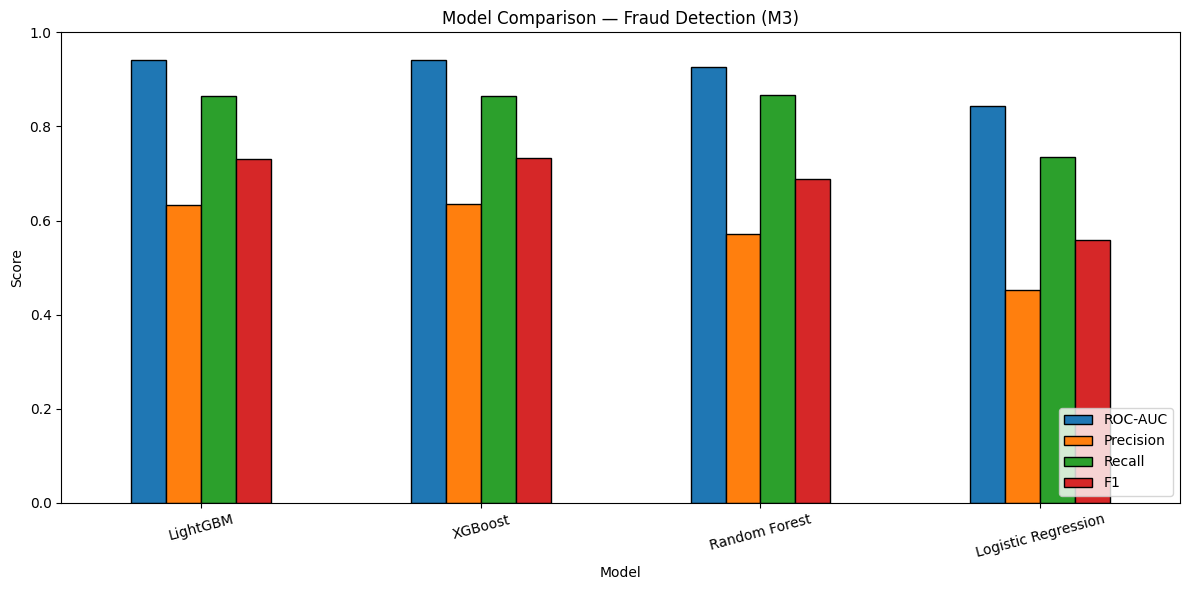

In [32]:
results = pd.DataFrame({
    'Model':     ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'ROC-AUC':   [roc_auc_score(y_test, y_proba_lr),
                  roc_auc_score(y_test, y_proba_rf),
                  roc_auc_score(y_test, y_proba_xgb),
                  roc_auc_score(y_test, y_proba_lgbm)],
    'Precision': [precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_xgb),
                  precision_score(y_test, y_pred_lgbm)],
    'Recall':    [recall_score(y_test, y_pred_lr),
                  recall_score(y_test, y_pred_rf),
                  recall_score(y_test, y_pred_xgb),
                  recall_score(y_test, y_pred_lgbm)],
    'F1':        [f1_score(y_test, y_pred_lr),
                  f1_score(y_test, y_pred_rf),
                  f1_score(y_test, y_pred_xgb),
                  f1_score(y_test, y_pred_lgbm)],
})

results = results.round(4).sort_values('ROC-AUC', ascending=False)
print(results.to_string(index=False))

# Plot comparison
results.set_index('Model')[['ROC-AUC','Precision','Recall','F1']].plot(
    kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Model Comparison — Fraud Detection (M3)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 8 — Best Model: Confusion Matrix & ROC Curve

Whichever model has the highest ROC-AUC is selected as the
**best model** for M3. We visualize its confusion matrix and ROC curve.

🏆 Best model: LightGBM


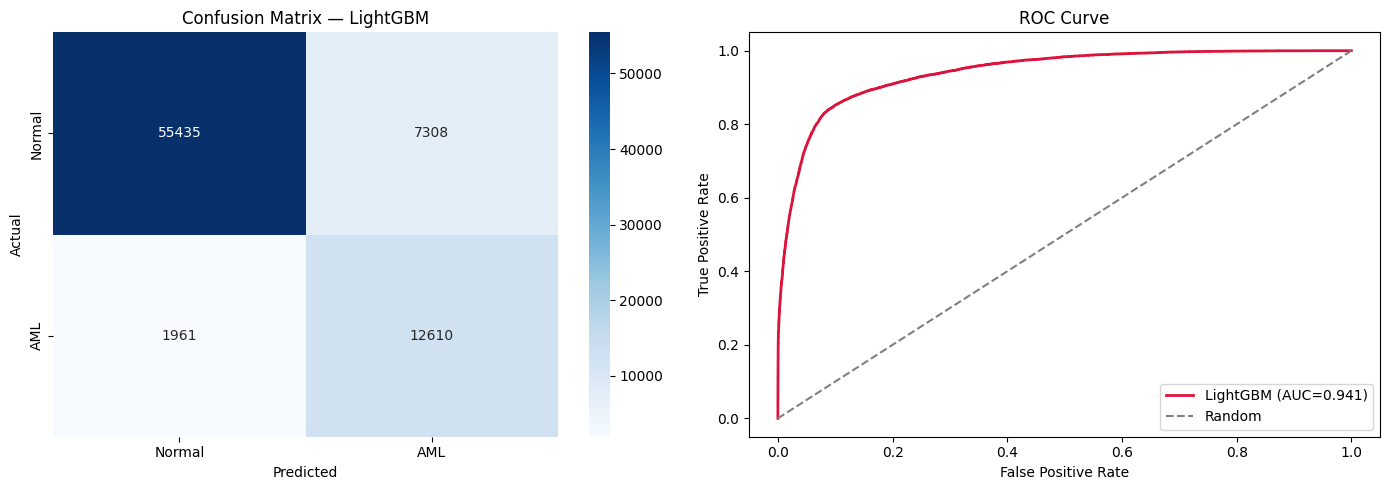


              precision    recall  f1-score   support

      Normal       0.97      0.88      0.92     62743
         AML       0.63      0.87      0.73     14571

    accuracy                           0.88     77314
   macro avg       0.80      0.87      0.83     77314
weighted avg       0.90      0.88      0.89     77314



In [33]:
# Pick best model automatically based on ROC-AUC
best_model_name = results.iloc[0]['Model']
print(f"🏆 Best model: {best_model_name}")

model_map = {
    'Logistic Regression': (log_reg, y_pred_lr, y_proba_lr),
    'Random Forest':       (rf, y_pred_rf, y_proba_rf),
    'XGBoost':             (xgb, y_pred_xgb, y_proba_xgb),
    'LightGBM':            (lgbm, y_pred_lgbm, y_proba_lgbm),
}
best_model, y_pred_best, y_proba_best = model_map[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','AML'],
            yticklabels=['Normal','AML'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {best_model_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ── ROC Curve ──────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
axes[1].plot(fpr, tpr, label=f'{best_model_name} (AUC={roc_auc_score(y_test, y_proba_best):.3f})',
             color='crimson', linewidth=2)
axes[1].plot([0,1], [0,1], linestyle='--', color='gray', label='Random')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_best,
                            target_names=['Normal', 'AML']))

## Step 9 — Feature Importance of Best Model

Top 20 features driving fraud predictions.

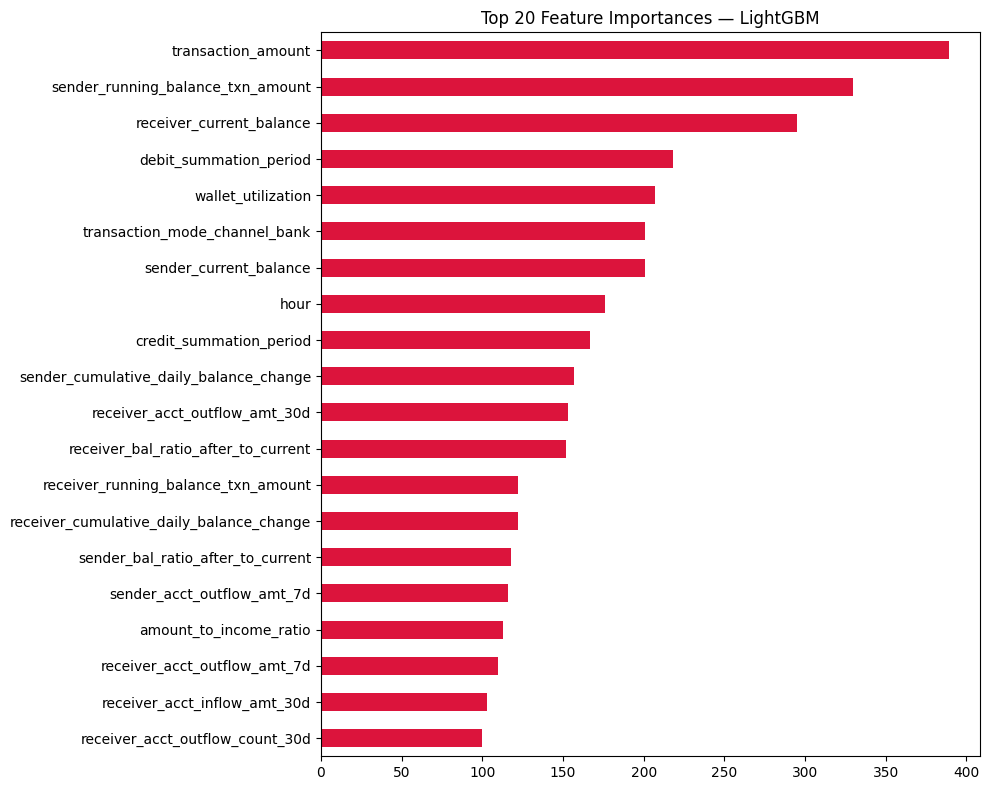

transaction_amount                        389
sender_running_balance_txn_amount         330
receiver_current_balance                  295
debit_summation_period                    218
wallet_utilization                        207
transaction_mode_channel_bank             201
sender_current_balance                    201
hour                                      176
credit_summation_period                   167
sender_cumulative_daily_balance_change    157
dtype: int32


In [34]:
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(10, 8))
    feat_imp.head(20).plot(kind='barh', color='crimson')
    plt.title(f'Top 20 Feature Importances — {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print(feat_imp.head(10))
else:
    print("Selected model doesn't expose feature_importances_ directly.")

## Step 10 — Save Best Model

Saving the best model + scaler + feature list for use in:
- M4 (typology classification — can reuse same features)
- M5 (final pipeline + SHAP explainability)

In [35]:
output_dir = os.path.join('..', 'outputs')
os.makedirs(output_dir, exist_ok=True)

# Save model
model_path = os.path.join(output_dir, 'fraud_detection_model.pkl')
joblib.dump(best_model, model_path)

# Save feature list (needed for inference later)
feature_list_path = os.path.join(output_dir, 'm3_feature_list.pkl')
joblib.dump(X.columns.tolist(), feature_list_path)

print("=" * 50)
print("✅ MODEL SAVED")
print("=" * 50)
print(f"  Model        : {model_path}")
print(f"  Feature list : {feature_list_path}")
print(f"  Best model   : {best_model_name}")
print(f"  ROC-AUC      : {results.iloc[0]['ROC-AUC']:.4f}")

✅ MODEL SAVED
  Model        : ..\outputs\fraud_detection_model.pkl
  Feature list : ..\outputs\m3_feature_list.pkl
  Best model   : LightGBM
  ROC-AUC      : 0.9412


## ✅ Milestone 3 Complete — Summary

| Step | Action | Result |
|---|---|---|
| Load | Model-ready data | 386,570 × 84 |
| Split | 80/20 train-test (stratified) | Same fraud ratio in both |
| Baseline | Logistic Regression | ROC-AUC, P, R, F1 computed |
| Models | Random Forest, XGBoost, LightGBM | All trained & compared |
| Best model | Auto-selected by ROC-AUC | Confusion matrix + ROC curve |
| Feature importance | Top 20 shown | Aligns with EDA findings |
| Saved | fraud_detection_model.pkl | Ready for M4/M5 |

### Files saved in outputs/:
- `fraud_detection_model.pkl`
- `m3_feature_list.pkl`

### Next → Milestone 4: AML Typology Classification
